## Importación de librería y datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [2]:
ruta_docentes = (
    Path("..") / ".." / "Recursos"
    / "Dataset docentes concatenado"
    / "dataset_docentes_consolidado.parquet"
)
print(ruta_docentes.exists())
df_d = pd.read_parquet(ruta_docentes)
print(df_d.shape)

True
(379153, 14)


In [4]:
ruta_estudiantes = (
    Path("..") / ".." / "Recursos"
    / "Dataset estudiantes concatenado"
    / "dataset_estudiantes_consolidado.parquet"
)
print(ruta_estudiantes.exists())
df_e = pd.read_parquet(ruta_estudiantes)
print(df_e.shape)

True
(4560711, 21)


In [19]:
for i, col in enumerate(df_e.columns, start=1):
    print(f"{i}. {col}")

1. Id persona
2. Sexo
3. Rol
4. Departamento
5. Subsistema
6. Ciclo
7. Grado
8. Zona
9. Contexto
10. Año lectivo
11. Cantidad de días ingreso a CREA
12. Cantidad de entregas de tareas
13. Cantidad de Comentarios posteados
14. Cantidad de Acciones totales
15. Cantidad de días de ingreso a Matific
16. Cantidad de episodios finalizados en Matific
17. Cantidad de días de ingreso a PAM
18. Cantidad de actividades finalizadas en PAM
19. Cantidad de días de ingreso a Biblioteca
20. Cantidad de préstamos en biblioteca
21. archivo_origen


In [6]:
df_d["comentarios"] = df_d["Cantidad de Comentarios posteados"].combine_first(
    df_d["Cantidad de Comentarios posteados en CREA"]
)
df_d["acciones"] = df_d["Cantidad de Acciones totales"].combine_first(
    df_d["Cantidad de Acciones totales en CREA"]
)
df_d = df_d.drop(columns=[
    "Cantidad de Comentarios posteados", "Cantidad de Comentarios posteados en CREA",
    "Cantidad de Acciones totales", "Cantidad de Acciones totales en CREA",
])

## Exploración de los datos - DataFrame Docente

In [16]:
# Listado de columnas en el DF de docentes (df_d)
for i, col in enumerate(df_d.columns, start=1):
    print(f"{i}. {col}")

1. Id persona
2. Sexo
3. Rol
4. Departamento
5. Subsistema
6. Año lectivo
7. Cantidad de días ingreso a CREA
8. Cantidad de días de ingreso a Biblioteca
9. Cantidad de préstamos en biblioteca
10. archivo_origen
11. comentarios
12. acciones


In [7]:
df_d["Sexo"].value_counts()

Sexo
Femenino      243968
Masculino      78631
Femenino       42469
Masculino      13605
Sin Dato         480
Name: count, dtype: int64

In [9]:
df_d.head()

,Id persona,Sexo,Rol,Departamento,Subsistema,Año lectivo,Cantidad de días ingreso a CREA,Cantidad de días de ingreso a Biblioteca,Cantidad de préstamos en biblioteca,archivo_origen,comentarios,acciones
0,702122,Femenino,Docente,Montevideo,DGES,2024,0,0,0,actividad-de-docentes-2024.csv,0.0,0.0
1,199850,Masculino,Docente,Montevideo,DGETP,2024,0,0,0,actividad-de-docentes-2024.csv,0.0,0.0
2,1686169,Masculino,Docente,Salto,DGES,2024,0,0,0,actividad-de-docentes-2024.csv,0.0,0.0
3,1680863,Masculino,Docente,Montevideo,DGEIP,2024,0,0,0,actividad-de-docentes-2024.csv,0.0,0.0
4,1802728,Femenino,Docente,Paysandu,DGES,2024,0,0,0,actividad-de-docentes-2024.csv,0.0,0.0


In [10]:
pd.crosstab(df_d["archivo_origen"], df_d["Sexo"].map(repr))

Sexo,'Femenino ','Femenino','Masculino ','Masculino','Sin Dato'
archivo_origen,,,,,
actividad-de-docentes-2024.csv,0,41822,0,13342,1
actividad-de-docentes-2025.csv,42469,0,13605,0,0
datos_docentes_2019.csv,0,38806,0,12112,452
datos_docentes_2020.csv,0,38053,0,12066,3
datos_docentes_2021.csv,0,39787,0,12606,0
datos_docentes_2022.csv,0,41294,0,13188,13
docentes_datos_abiertos_agesic.csv,0,44206,0,15317,11


In [21]:
# Tenemos que limpiar los strings de la columna "Sexo"
# Al escribir el dataset, tuvieron un error tipográfico y agregaron a veces un espacio (" ") al final de la palabra
# Para Python, estos son dos cosas distintas. Así que debemos limpiarlas

df_d["Sexo"] = df_d["Sexo"].str.strip()
df_d["Sexo"].value_counts()

Sexo
Femenino     286437
Masculino     92236
Sin Dato        480
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

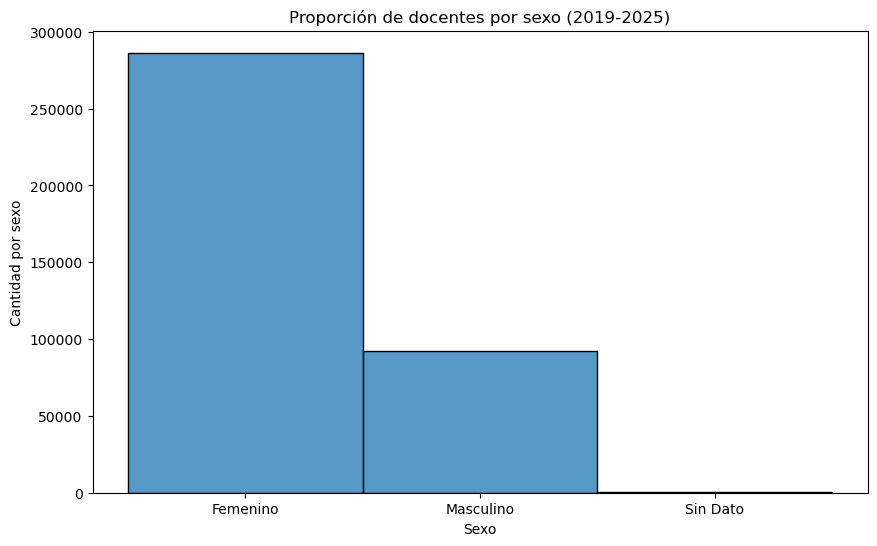

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_d,
    x="Sexo",
)
plt.title("Proporción de docentes por sexo (2019-2025)")
plt.xlabel("Sexo")
plt.ylabel("Cantidad por sexo")
plt.show

In [20]:
pd.crosstab(df_d["archivo_origen"], df_d["Subsistema"].map(repr))

Subsistema,'DGEIP ','DGEIP','DGES ','DGES','DGETP ','DGETP'
archivo_origen,,,,,,
actividad-de-docentes-2024.csv,0,20203,0,20931,0,14031
actividad-de-docentes-2025.csv,20380,0,21180,0,14514,0
datos_docentes_2019.csv,0,18968,0,20239,0,12163
datos_docentes_2020.csv,0,18050,0,19644,0,12428
datos_docentes_2021.csv,0,20002,0,19561,0,12830
datos_docentes_2022.csv,0,20125,0,21205,0,13165
docentes_datos_abiertos_agesic.csv,0,19954,0,26214,0,13366


In [22]:
# Al igual que antes, debemos limpiar los espacios en blanco de la columna "Subsistema"

df_d["Subsistema"] = df_d["Subsistema"].str.strip()
df_d["Subsistema"].value_counts()

Subsistema
DGES     148974
DGEIP    137682
DGETP     92497
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

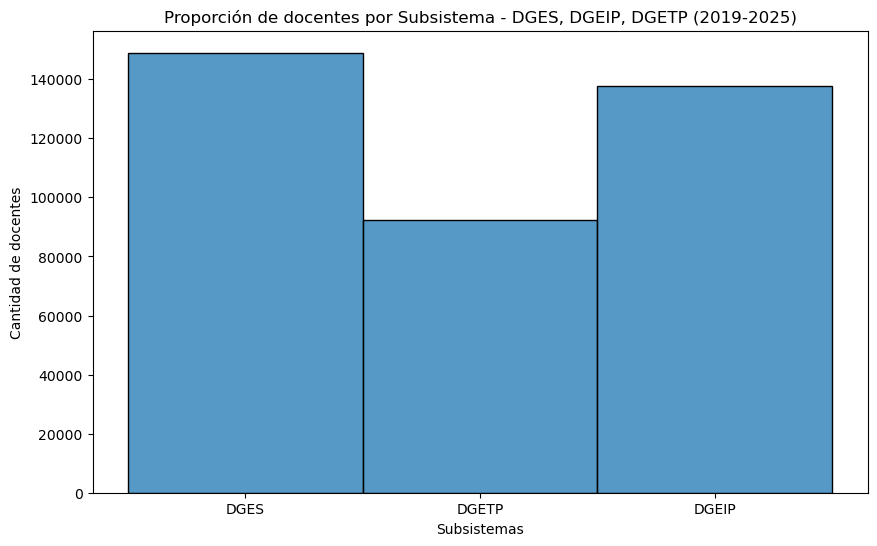

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_d,
    x="Subsistema",
)
plt.title("Proporción de docentes por Subsistema - DGES, DGEIP, DGETP (2019-2025)")
plt.xlabel("Subsistemas")
plt.ylabel("Cantidad de docentes")
plt.show